# Phương pháp 2: Phân tích Truyền Tín Hiệu (Signal Propagation)

## Mục tiêu

Phân tích forward pass và backward pass khi đầu vào có tương quan cao:
- **Forward pass**: chứng minh phương sai hidden state $E[h_k^2]$ tăng vô hạn khi $k\to\infty$
- **Backward pass**: chứng minh độ nhạy gradient $(dh_k/d\lambda)$ bùng nổ nhanh hơn forward

Điều này chứng minh rằng dù không có exploding gradients theo nghĩa cổ điển, việc học vẫn trở nên cực kỳ khó khăn.

## Lý thuyết

Với mô hình $h_{k+1} = \lambda h_k + x_k$:

**Forward (uncorrelated $x_i \sim \mathcal{N}(0,1)$):**
$$E[h_k^2] = \sum_{i=0}^{k-1}\lambda^{2(k-1-i)} = \frac{1-\lambda^{2k}}{1-\lambda^2} \xrightarrow{k\to\infty} \frac{1}{1-\lambda^2}$$

**Forward (correlated $x_i$, AR(1) noise với $\rho$):**
$$E[h_k^2] \to \infty \text{ khi } \rho\lambda \to 1$$

**Backward**:
$$\text{Var}(\partial h_k/\partial \lambda) \sim k^3 \text{ khi } \lambda\to 1$$

Tốc độ tăng backward ($k^3$) >> forward ($k$ hoặc bị bounded).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Bước 1: Sinh đầu vào — uncorrelated vs correlated (AR(1))

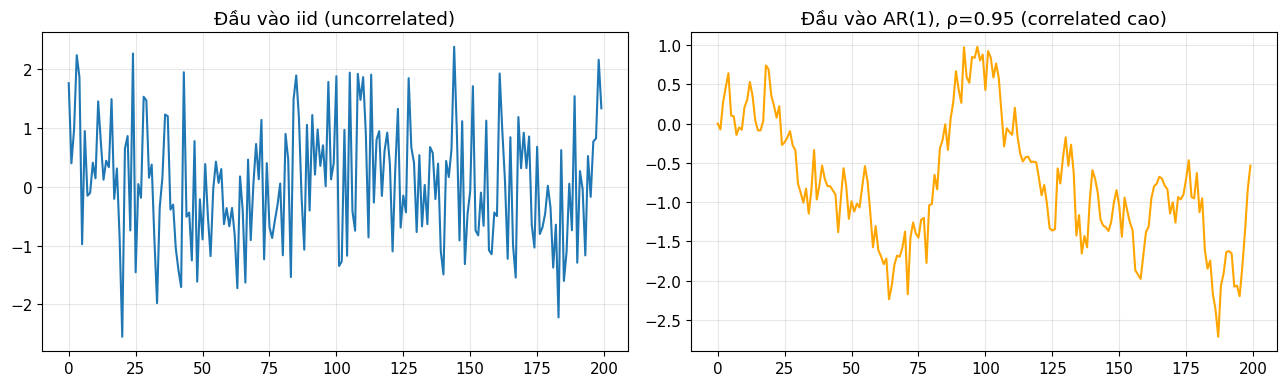

In [2]:
def gen_uncorrelated(T):
    return np.random.randn(T)

def gen_ar1(T, rho=0.9):
    """AR(1): x_t = rho * x_{t-1} + eps_t"""
    x = np.zeros(T)
    eps = np.random.randn(T) * np.sqrt(1 - rho**2)
    for t in range(1, T):
        x[t] = rho * x[t-1] + eps[t]
    return x

T = 200
x_iid = gen_uncorrelated(T)
x_ar = gen_ar1(T, rho=0.95)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_iid)
axes[0].set_title('Đầu vào iid (uncorrelated)')
axes[0].grid(alpha=0.3)
axes[1].plot(x_ar, color='orange')
axes[1].set_title('Đầu vào AR(1), ρ=0.95 (correlated cao)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 2: Forward pass — phương sai E[h²_k]

In [3]:
def simulate_rnn(lam, x):
    T = len(x)
    h = np.zeros(T + 1)
    for k in range(T):
        h[k+1] = lam * h[k] + x[k]
    return h

def estimate_E_h_sq(lam, gen_x_fn, T, n_samples=2000):
    """Monte Carlo estimate of E[h_k^2] for k=0..T"""
    H_sq = np.zeros(T + 1)
    for s in range(n_samples):
        x = gen_x_fn(T)
        h = simulate_rnn(lam, x)
        H_sq += h**2
    return H_sq / n_samples

lambdas = [0.5, 0.9, 0.99]
T_long = 300
results_iid = {l: estimate_E_h_sq(l, gen_uncorrelated, T_long) for l in lambdas}
results_ar = {l: estimate_E_h_sq(l, lambda T: gen_ar1(T, 0.95), T_long) for l in lambdas}
print('Đã ước lượng E[h_k²] cho cả hai loại đầu vào.')

Đã ước lượng E[h_k²] cho cả hai loại đầu vào.


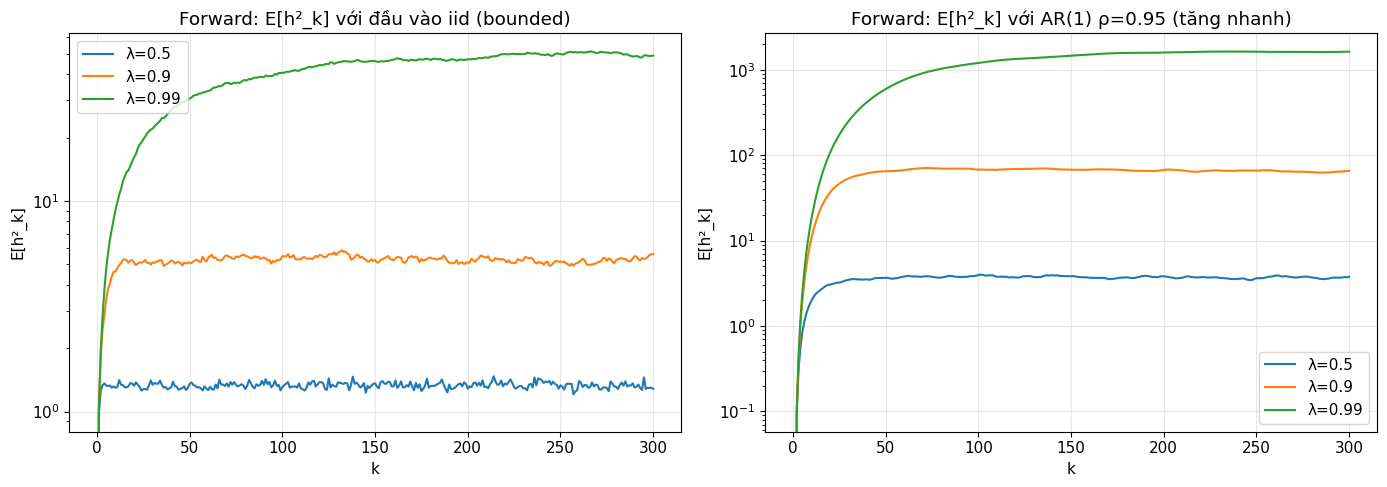

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_arr = np.arange(T_long + 1)

for lam in lambdas:
    axes[0].plot(k_arr, results_iid[lam], label=f'λ={lam}')
    axes[1].plot(k_arr, results_ar[lam], label=f'λ={lam}')

axes[0].set_title('Forward: E[h²_k] với đầu vào iid (bounded)')
axes[1].set_title('Forward: E[h²_k] với AR(1) ρ=0.95 (tăng nhanh)')
for ax in axes:
    ax.set_xlabel('k'); ax.set_ylabel('E[h²_k]'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

**Quan sát**: Với đầu vào tương quan cao (AR(1)), phương sai forward tăng nhanh hơn nhiều, đặc biệt khi λ→1. Đây chính là sự cộng hưởng giữa tương quan input và memory dài.

## Bước 3: Backward pass — Var(∂h_k/∂λ)

In [5]:
def dh_dlambda(lam, x):
    T = len(x)
    h = np.zeros(T + 1); d = np.zeros(T + 1)
    for k in range(T):
        d[k+1] = h[k] + lam * d[k]
        h[k+1] = lam * h[k] + x[k]
    return d

def estimate_var_grad(lam, gen_x_fn, T, n_samples=2000):
    derivs = np.zeros((n_samples, T + 1))
    for s in range(n_samples):
        x = gen_x_fn(T)
        derivs[s] = dh_dlambda(lam, x)
    return derivs.var(axis=0)

grad_var_iid = {l: estimate_var_grad(l, gen_uncorrelated, T_long) for l in lambdas}
grad_var_ar = {l: estimate_var_grad(l, lambda T: gen_ar1(T, 0.95), T_long) for l in lambdas}
print('Đã ước lượng Var(∂h_k/∂λ).')

Đã ước lượng Var(∂h_k/∂λ).


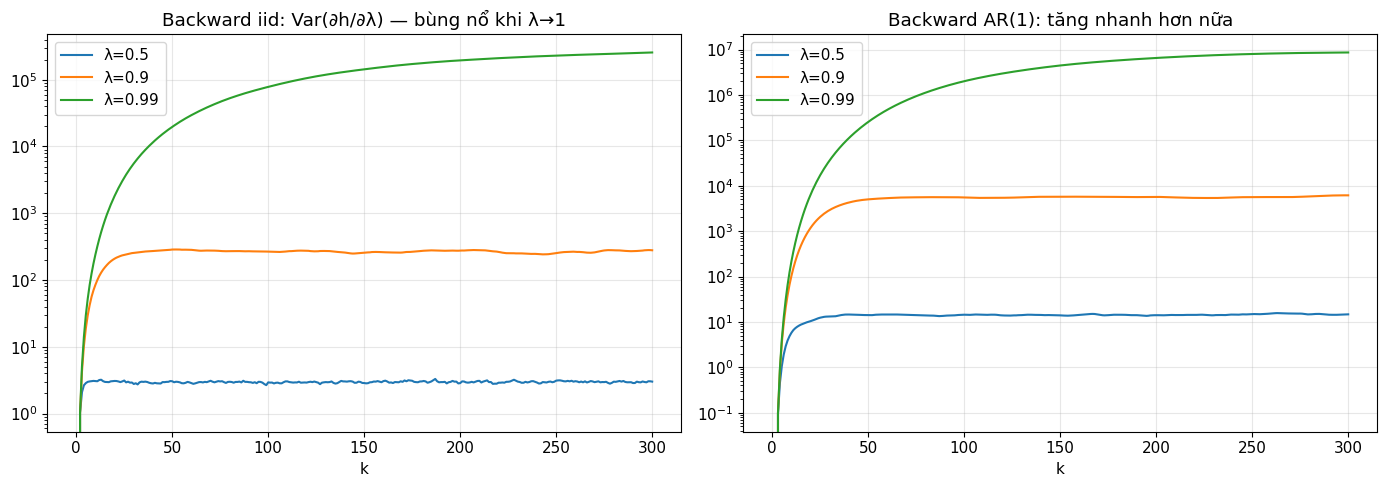

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lam in lambdas:
    axes[0].plot(k_arr, grad_var_iid[lam], label=f'λ={lam}')
    axes[1].plot(k_arr, grad_var_ar[lam], label=f'λ={lam}')
axes[0].set_title('Backward iid: Var(∂h/∂λ) — bùng nổ khi λ→1')
axes[1].set_title('Backward AR(1): tăng nhanh hơn nữa')
for ax in axes:
    ax.set_yscale('log'); ax.set_xlabel('k'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 4: So sánh tốc độ tăng Forward vs Backward

Để thấy rõ backward bùng nổ nhanh hơn forward, vẽ tỉ số `Var(dh/dλ) / E[h²]`.

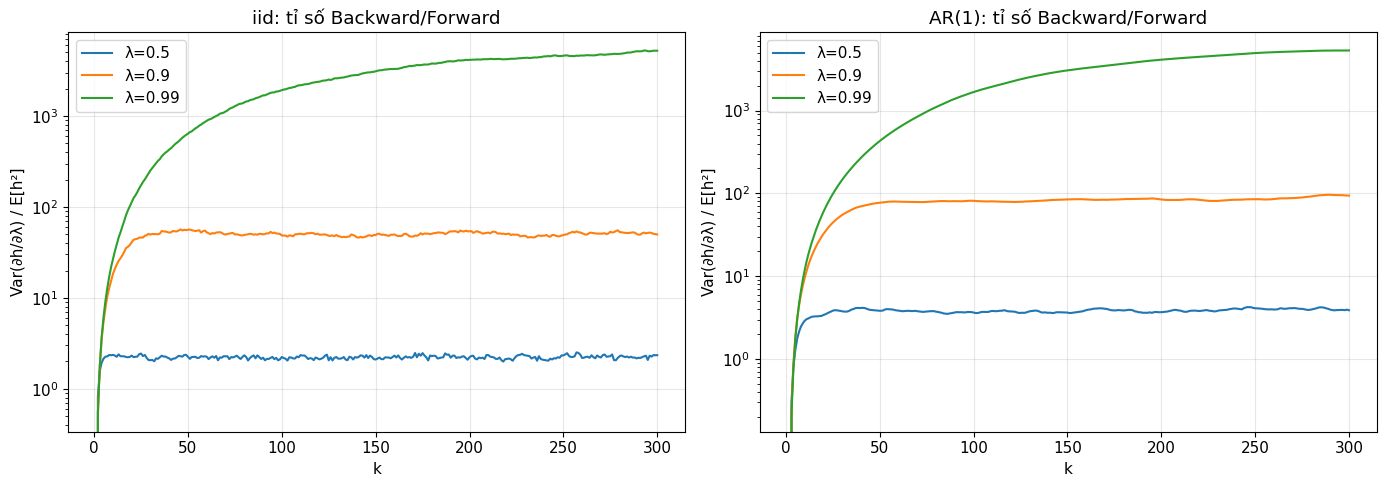

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lam in lambdas:
    ratio_iid = grad_var_iid[lam][1:] / (results_iid[lam][1:] + 1e-12)
    ratio_ar = grad_var_ar[lam][1:] / (results_ar[lam][1:] + 1e-12)
    axes[0].plot(k_arr[1:], ratio_iid, label=f'λ={lam}')
    axes[1].plot(k_arr[1:], ratio_ar, label=f'λ={lam}')
axes[0].set_title('iid: tỉ số Backward/Forward')
axes[1].set_title('AR(1): tỉ số Backward/Forward')
for ax in axes:
    ax.set_yscale('log'); ax.set_xlabel('k'); ax.set_ylabel('Var(∂h/∂λ) / E[h²]')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Quan sát**: Tỉ số tăng tuyến tính theo $k$ ở đầu vào iid, và còn nhanh hơn ở AR(1). Điều này chứng minh **backward sensitivity bùng nổ độc lập với forward signal**.

## Bước 5: Heatmap — Phân vùng (λ, ρ) ổn định và bất ổn định

In [8]:
lam_arr = np.linspace(0.0, 0.99, 25)
rho_arr = np.linspace(0.0, 0.99, 25)
T_grid = 100
grad_var_grid = np.zeros((len(rho_arr), len(lam_arr)))
for i, rho in enumerate(tqdm(rho_arr, desc='Quét lưới')):
    for j, lam in enumerate(lam_arr):
        var_curve = estimate_var_grad(lam, lambda T: gen_ar1(T, rho), T_grid, n_samples=500)
        grad_var_grid[i, j] = var_curve[-1]
print('Done.')

Quét lưới:   0%|          | 0/25 [00:00<?, ?it/s]

Done.


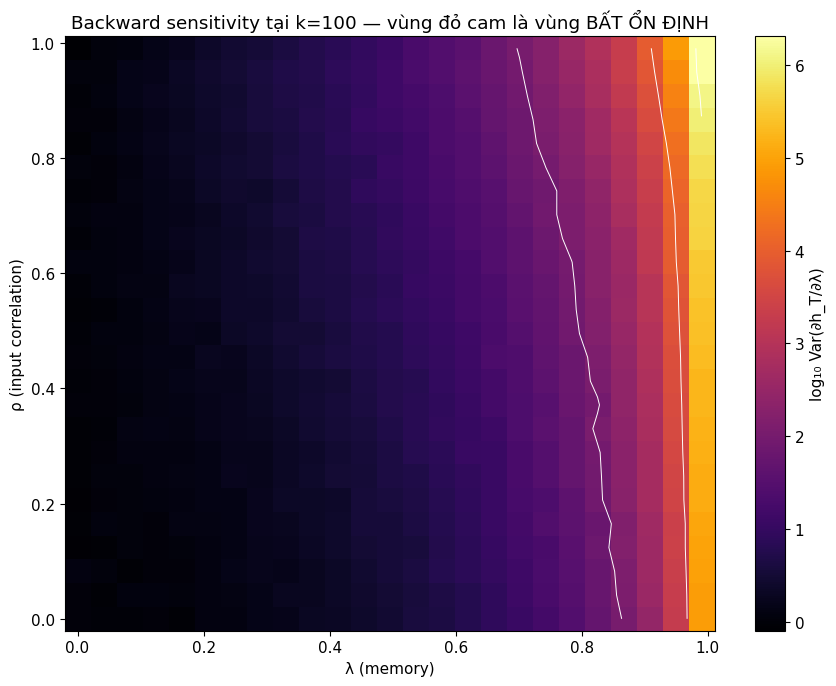

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(lam_arr, rho_arr, np.log10(grad_var_grid + 1e-12), 
                    shading='auto', cmap='inferno')
plt.colorbar(im, ax=ax, label='log₁₀ Var(∂h_T/∂λ)')
ax.set_xlabel('λ (memory)')
ax.set_ylabel('ρ (input correlation)')
ax.set_title(f'Backward sensitivity tại k={T_grid} — vùng đỏ cam là vùng BẤT ỔN ĐỊNH')
ax.contour(lam_arr, rho_arr, np.log10(grad_var_grid + 1e-12), levels=[2, 4, 6], colors='white', linewidths=0.7)
plt.tight_layout()
plt.show()

## Kết luận phương pháp 2

- **Forward pass** với đầu vào tương quan cao ($\rho \to 1$) khiến $E[h_k^2]$ tăng vô hạn.
- **Backward pass** luôn tăng nhanh hơn forward, theo bậc $\mathcal{O}(k^3)$ khi $\lambda \to 1$.
- Vùng $(\lambda, \rho)$ gần $(1, 1)$ là vùng bất ổn định mạnh nhất — đặc biệt nguy hiểm cho dữ liệu thực tế (ngôn ngữ, time series).
- Điều này chứng minh rằng dù không có exploding gradients (vì $|\lambda|<1$), việc học vẫn cực kỳ khó khăn vì gradient có phương sai cực lớn.